--- Nhóm phong cách thi đấu của các siêu sao ---


,player,club,Cluster,sprint_speed,finishing,short_pass,slide_tackle,dribbling,strength
2381,Ronaldo Damus,GIF Sundsvall,1,77,63,52,20,60,69
3401,Ronaldo Cabrais,Brazil,1,87,74,83,33,85,68
5229,Kylian Mbappé,Paris SG,1,97,93,85,32,93,76
5365,Ronaldo Vieira,Torino,2,76,53,72,68,71,71
5675,Kylian Mbappé,Paris SG,1,97,93,85,32,93,76
5680,Cristiano Ronaldo,Al Nassr,1,82,91,78,24,81,75


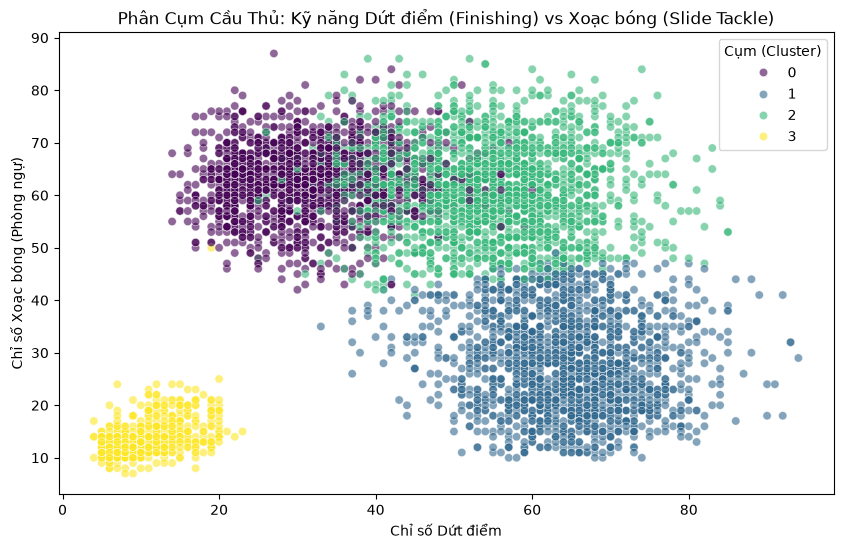

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# 1. Đọc và làm sạch dữ liệu cơ bản (Load lại dữ liệu cho phiên làm việc mới)
def read_player_stats(path):
    """Đọc CSV theo từng dòng: thử UTF-8 trước, dòng nào lỗi (bị lưu bằng Latin-1)
    thì fallback sang Latin-1 cho đúng dòng đó. Tránh lỗi font kiểu 'JoÃ£o' do
    đọc toàn bộ file bằng encoding='latin-1' trước đây."""
    from io import StringIO
    lines = []
    with open(path, 'rb') as f:
        for line in f:
            try:
                lines.append(line.decode('utf-8'))
            except UnicodeDecodeError:
                lines.append(line.decode('latin-1'))
    return pd.read_csv(StringIO(''.join(lines)))

df = read_player_stats('../data/player_stats.csv')
df_cleaned = df.drop(columns=['marking'])

# 2. Lựa chọn tập thuộc tính đặc trưng cho lối chơi trên sân
features = ['sprint_speed', 'finishing', 'short_pass', 'slide_tackle', 'dribbling', 'strength']

# Đảm bảo không còn giá trị khuyết (điền bằng giá trị trung bình)
df_cleaned[features] = df_cleaned[features].fillna(df_cleaned[features].mean())

# 3. Chuẩn hóa tập thuộc tính mới này
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_cleaned[features])

# 4. Triển khai thuật toán K-Means
# Khởi tạo K=4 để chia thành 4 nhóm (Ví dụ: Tiền đạo, Tiền vệ, Hậu vệ, Thủ môn/Dự bị)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# Tiến hành phân cụm và gán nhãn cụm (Cluster) vào dataframe gốc
df_cleaned['Cluster'] = kmeans.fit_predict(X_scaled)

# 5. Quan sát kết quả phân cụm của các siêu sao
superstars = df_cleaned[df_cleaned['player'].str.contains('Ronaldo|Mbappé', na=False, case=False)]
print("--- Nhóm phong cách thi đấu của các siêu sao ---")
display(superstars[['player', 'club', 'Cluster'] + features])

# 6. Trực quan hóa dữ liệu (Clustering Visualization)
plt.figure(figsize=(10, 6))
# Đồ thị phân tán (Scatter plot) để xem sự tách biệt giữa kỹ năng Dứt điểm và Phòng ngự
sns.scatterplot(
    data=df_cleaned, 
    x='finishing', 
    y='slide_tackle', 
    hue='Cluster', 
    palette='viridis', 
    alpha=0.6
)
plt.title('Phân Cụm Cầu Thủ: Kỹ năng Dứt điểm (Finishing) vs Xoạc bóng (Slide Tackle)')
plt.xlabel('Chỉ số Dứt điểm')
plt.ylabel('Chỉ số Xoạc bóng (Phòng ngự)')
plt.legend(title='Cụm (Cluster)')
plt.show()


Cụm 0 (Màu tím - Hậu vệ): Kỹ năng phòng ngự cực tốt (trục tung cao) nhưng khả năng dứt điểm hạn chế (trục hoành thấp). 

Cụm 1 (Màu xanh dương - Tiền đạo): Dứt điểm (Finishing) rất cao nhưng Xoạc bóng (Slide Tackle) thấp. Bảng dữ liệu cũng xác nhận Cristiano Ronaldo và Kylian Mbappé đều được thuật toán tự động xếp chính xác vào nhóm tấn công này.

Cụm 2 (Màu xanh lá - Tiền vệ): Các chấm phân bố ở khu vực giữa đồ thị, thể hiện sự cân bằng giữa cả tấn công và phòng ngự (hoạt động rộng như các tiền vệ trung tâm - box to box).

Cụm 3 (Màu vàng - Thủ môn): Nằm gọn ở góc trái dưới cùng vì nhóm cầu thủ này hiếm khi dứt điểm hay xoạc bóng bằng chân trên sân.